In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix, mean_squared_error, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv("../data/final/base_dataset.csv")
df_engagement = pd.read_csv("../data/final/engagement_features.csv")
df_reviews_feat = pd.read_csv("../data/final/review_features.csv")
df_support = pd.read_csv("../data/final/support_features.csv")
df_money = pd.read_csv("../data/final/money_features.csv")

In [46]:
print(df.shape)
print(df_engagement.shape)
print(df_reviews_feat.shape)
print(df_support.shape)
print(df_money.shape)

(480, 13)
(480, 16)
(480, 15)
(480, 16)
(480, 15)


In [47]:
df = df_engagement.merge(
    df_reviews_feat[["app_id", "positive_percent", "review_score_bucket"]],
    on="app_id",
    how="left"
)

df = df.merge(
    df_support[["app_id", "days_since_update", "recent_update", "has_patchnotes"]],
    on="app_id",
    how="left"
)

df = df.merge(
    df_money[["app_id", "is_paid", "price_bucket"]],
    on="app_id",
    how="left"
)

df.head()

,app_id,name,release_date,is_free,price_usd,dlc_count,total_reviews,total_positive,total_negative,positive_ratio,...,game_age_days,players_per_review,log_players,positive_percent,review_score_bucket,days_since_update,recent_update,has_patchnotes,is_paid,price_bucket
0,10,Counter-Strike,2000-11-01,0,9.99,0,34614.0,33453.0,1161.0,0.966459,...,9316.0,0.378373,9.480215,0.966459,excellent,874.0,False,True,-1,free
1,20,Team Fortress Classic,NaN,0,7.50,0,4192.0,3617.0,575.0,0.862834,...,NaN,0.011450,3.891820,0.862834,excellent,579.0,False,True,-1,free
2,30,Day of Defeat,2003-05-01,0,4.99,0,2142.0,1902.0,240.0,0.887955,...,8405.0,0.041550,4.499810,0.887955,excellent,2400.0,False,True,-1,cheap
3,40,Deathmatch Classic,2001-06-01,0,4.99,0,1262.0,1043.0,219.0,0.826466,...,9104.0,0.003170,1.609438,0.826466,good,2400.0,False,True,-1,cheap
4,50,Half-Life: Opposing Force,1999-11-01,0,4.99,0,13104.0,12496.0,608.0,0.953602,...,9682.0,0.008318,4.700480,0.953602,excellent,2400.0,False,True,-1,cheap


In [48]:
df.to_csv("../data/final/modeling_dataset.csv", index=False)

print("Modeling dataset saved.")

Modeling dataset saved.


In [49]:
model_df = df.copy()
print(df.shape)
model_df = model_df.replace([np.inf, -np.inf], np.nan)

model_df = model_df.dropna(subset=[
    "current_players",
    "total_reviews",
    "positive_ratio",
    "game_age_days",
    "days_since_update",

])

model_df.shape

(480, 23)


(332, 23)

In [50]:
features = [
    "total_reviews",
    "positive_ratio",
    "game_age_days",
    "days_since_update"
]

X = model_df[features]
y = model_df["log_players"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R² Score: 0.5155064462733339
MAE: 1.451078793193187


In [51]:
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": reg_model.coef_
})

coef_df.sort_values("coefficient", ascending=False)

,feature,coefficient
1,positive_ratio,2.259934
0,total_reviews,0.000012
2,game_age_days,-0.000106
3,days_since_update,-0.001204


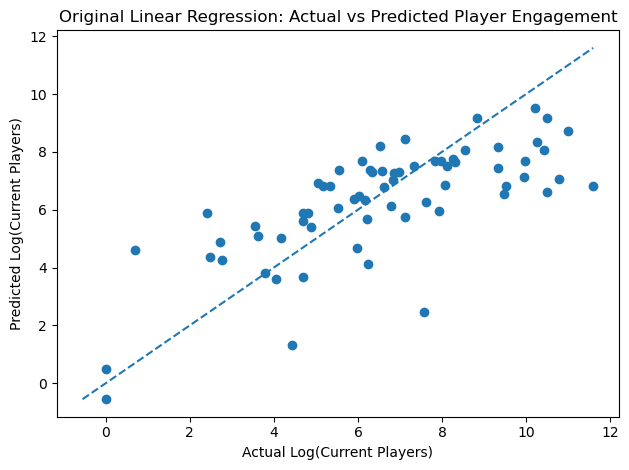

In [52]:
y_pred_original = reg_model.predict(X_test)

plt.scatter(y_test, y_pred_original)

plt.title("Original Linear Regression: Actual vs Predicted Player Engagement")
plt.xlabel("Actual Log(Current Players)")
plt.ylabel("Predicted Log(Current Players)")

# Perfect prediction reference line
min_val = min(y_test.min(), y_pred_original.min())
max_val = max(y_test.max(), y_pred_original.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()

In [53]:
model_df_improved = model_df.copy()

model_df_improved["log_total_reviews"] = np.log1p(model_df_improved["total_reviews"])

if "log_players" not in model_df_improved.columns:
    model_df_improved["log_players"] = np.log1p(model_df_improved["current_players"])

model_df_improved = model_df_improved.replace([np.inf, -np.inf], np.nan)

In [54]:
improved_features = [
    "log_total_reviews",
    "positive_ratio",
    "game_age_days",
    "days_since_update"
]

model_df_improved = model_df_improved.dropna(subset=improved_features + ["log_players"])

X = model_df_improved[improved_features]
y = model_df_improved["log_players"]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)

print("Improved Ridge Regression Results")
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Improved Ridge Regression Results
R² Score: 0.4927791606354093
MAE: 1.5135855696355058
RMSE: 1.8910323111307117


In [56]:
ridge_coefficients = ridge_model.named_steps["ridge"].coef_

ridge_coef_df = pd.DataFrame({
    "feature": improved_features,
    "coefficient": ridge_coefficients
}).sort_values("coefficient", ascending=False)

ridge_coef_df

,feature,coefficient
0,log_total_reviews,1.094427
1,positive_ratio,0.211483
2,game_age_days,-0.193707
3,days_since_update,-0.890549


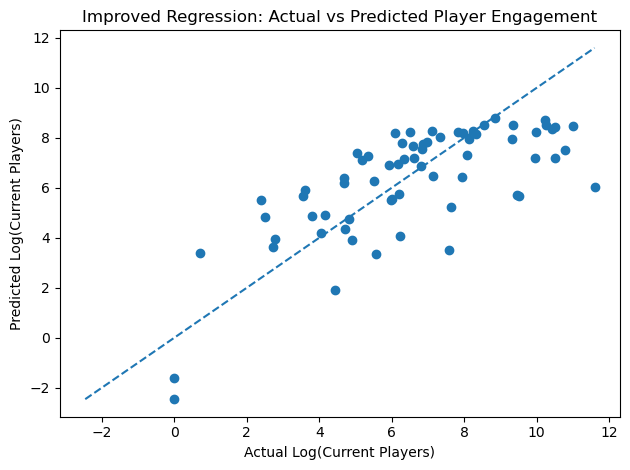

In [57]:
plt.scatter(y_test, y_pred)

plt.title("Improved Regression: Actual vs Predicted Player Engagement")
plt.xlabel("Actual Log(Current Players)")
plt.ylabel("Predicted Log(Current Players)")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()

In [59]:
threshold = model_df["current_players"].quantile(0.75)

model_df["high_staying_power"] = (
    model_df["current_players"] >= threshold
).astype(int)

print("Threshold:", threshold)
print(model_df["high_staying_power"].value_counts())

Threshold: 4423.0
high_staying_power
0    249
1     83
Name: count, dtype: int64


In [60]:
features = [
    "total_reviews",
    "positive_ratio",
    "game_age_days",
    "days_since_update"
]

X = model_df[features]
y = model_df["high_staying_power"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9104477611940298
[[49  1]
 [ 5 12]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        50
           1       0.92      0.71      0.80        17

    accuracy                           0.91        67
   macro avg       0.92      0.84      0.87        67
weighted avg       0.91      0.91      0.91        67



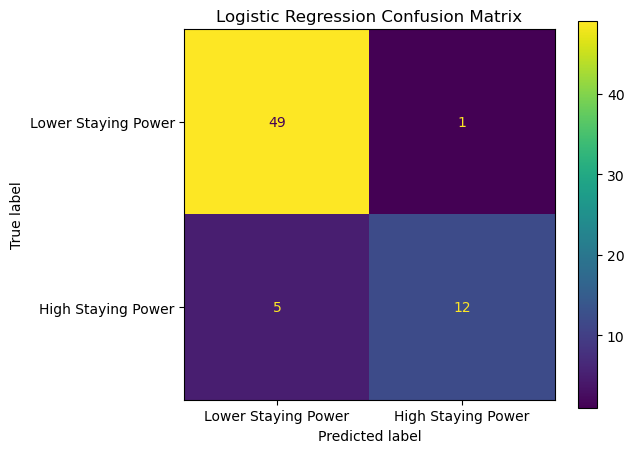

In [61]:
ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test,
    y_test,
    display_labels=["Lower Staying Power", "High Staying Power"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [67]:
y_prob = log_model.predict_proba(X_test)[:, 1]

prob_results = X_test.copy()
prob_results["app_id"] = model_df.loc[X_test.index, "app_id"]
prob_results["name"] = model_df.loc[X_test.index, "name"]
prob_results["actual"] = y_test.values
prob_results["predicted"] = y_pred
prob_results["success_probability"] = y_prob

prob_results.head()

,total_reviews,positive_ratio,game_age_days,days_since_update,app_id,name,actual,predicted,success_probability
10,44485.0,0.960773,7855.0,440.0,240,Counter-Strike: Source,1,0,0.050942
217,52874.0,0.958883,2541.0,95.0,620980,Beat Saber,0,0,0.396510
284,14284.0,0.880006,2784.0,586.0,880940,Pummel Party,0,0,0.040882
196,169155.0,0.978676,2183.0,63.0,548430,Deep Rock Galactic,1,1,0.877099
182,58800.0,0.974235,3022.0,1862.0,504230,Celeste,0,0,0.000542


In [68]:
prob_results.sort_values("success_probability", ascending=False).head(10)

,total_reviews,positive_ratio,game_age_days,days_since_update,app_id,name,actual,predicted,success_probability
87,579520.0,0.840734,4040.0,2.0,271590,Grand Theft Auto V Legacy,1,1,0.999936
316,372979.0,0.887575,1973.0,5.0,1091500,Cyberpunk 2077,1,1,0.997773
204,278515.0,0.634264,3057.0,2.0,578080,PUBG: BATTLEGROUNDS,1,1,0.985087
55,175510.0,0.741855,2700.0,13.0,221100,DayZ,1,1,0.904027
196,169155.0,0.978676,2183.0,63.0,548430,Deep Rock Galactic,1,1,0.877099
53,174138.0,0.872871,4648.0,29.0,218620,PAYDAY 2,1,1,0.855093
135,181110.0,0.810182,3830.0,168.0,377160,Fallout 4,1,1,0.818544
71,175470.0,0.952972,2927.0,213.0,242760,The Forest,1,1,0.794365
306,140718.0,0.913074,1180.0,152.0,990080,Hogwarts Legacy,1,1,0.779597
157,114780.0,0.982863,2090.0,46.0,427520,Factorio,1,1,0.735503


In [70]:
misclassified = prob_results[
    prob_results["actual"] != prob_results["predicted"]
].copy()

misclassified = misclassified.sort_values(
    "success_probability",
    ascending=False
)

misclassified

,total_reviews,positive_ratio,game_age_days,days_since_update,app_id,name,actual,predicted,success_probability
407,126207.0,0.984842,1293.0,185.0,1794680,Vampire Survivors,0,1,0.694472
382,38960.0,0.694482,1544.0,19.0,1599340,Lost Ark,1,0,0.464415
192,20073.0,0.706870,1288.0,4.0,529340,Victoria 3,1,0,0.402431
30,78105.0,0.955163,5705.0,525.0,8930,Sid Meier's Civilization® V,1,0,0.095798
10,44485.0,0.960773,7855.0,440.0,240,Counter-Strike: Source,1,0,0.050942
0,34614.0,0.966459,9316.0,874.0,10,Counter-Strike,1,0,0.005915


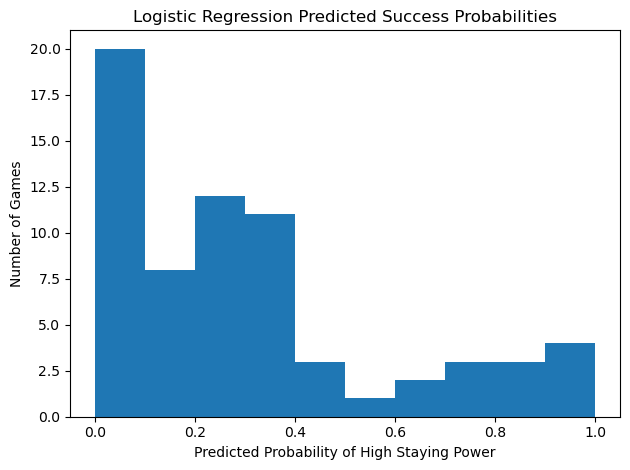

In [62]:
y_prob = log_model.predict_proba(X_test)[:, 1]

plt.hist(y_prob, bins=10)

plt.title("Logistic Regression Predicted Success Probabilities")
plt.xlabel("Predicted Probability of High Staying Power")
plt.ylabel("Number of Games")

plt.tight_layout()
plt.show()

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8507462686567164
[[45  5]
 [ 5 12]]
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        50
           1       0.71      0.71      0.71        17

    accuracy                           0.85        67
   macro avg       0.80      0.80      0.80        67
weighted avg       0.85      0.85      0.85        67



In [21]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values("importance", ascending=False)
importance_df

,feature,importance
0,total_reviews,0.337680
3,days_since_update,0.319139
2,game_age_days,0.203868
1,positive_ratio,0.139313


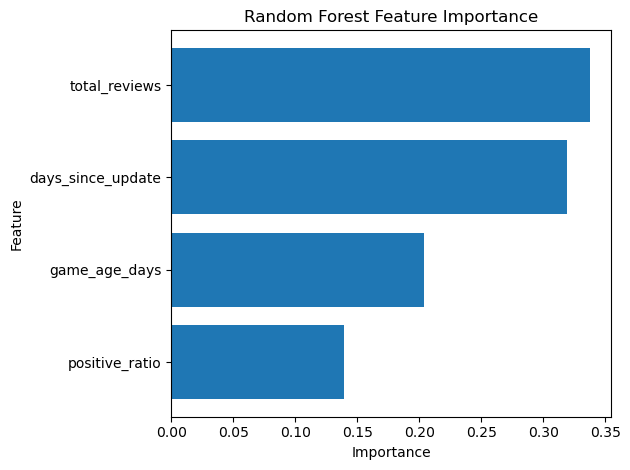

In [22]:
importance_plot = importance_df.sort_values("importance", ascending=True)

plt.barh(importance_plot["feature"], importance_plot["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()